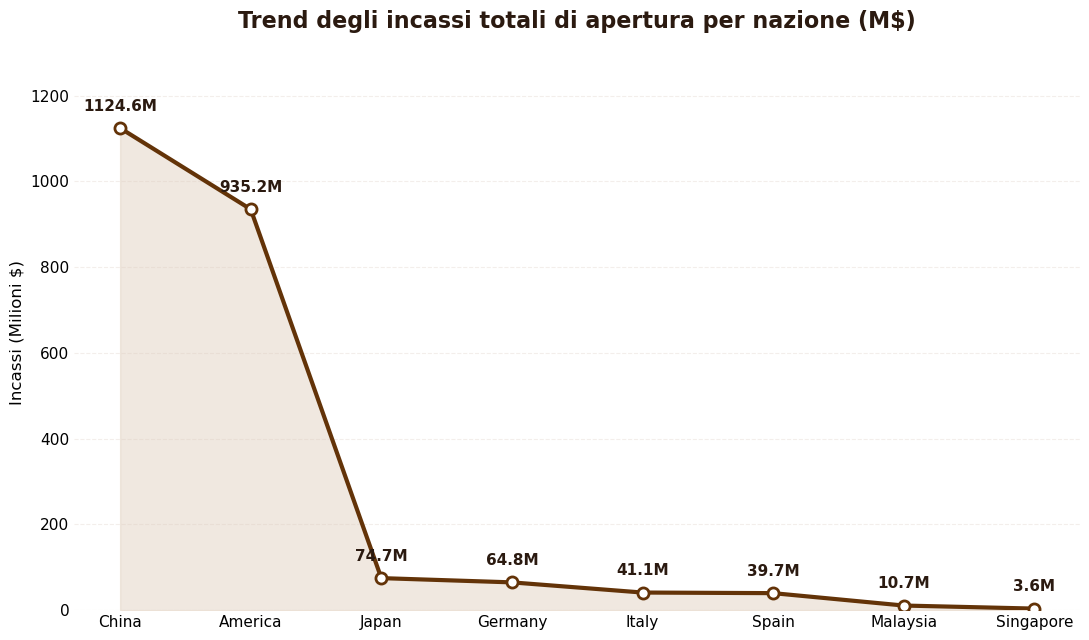

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

def parse_money_eu(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    if s.lower() in ["", "-", "nan", "none"]:
        return np.nan
    s = re.sub(r"[€$]", "", s)
    s = s.replace(" ", "")
    s = re.sub(r"[^0-9,\.]", "", s)

    if s == "":
        return np.nan

    if "," in s and "." in s:
        s = s.replace(".", "").replace(",", ".")
    else:
        if s.count(".") >= 2 and "," not in s:
            s = s.replace(".", "")
        elif s.count(",") >= 2 and "." not in s:
            s = s.replace(",", "")
        else:
            if "," in s and "." not in s:
                s = s.replace(".", "").replace(",", ".")
            elif "." in s and "," not in s:
                parts = s.split(".")
                if len(parts[-1]) == 3 and all(len(p) <= 3 for p in parts[:-1]):
                    s = "".join(parts)

    try:
        return float(s)
    except:
        return np.nan

opening = pd.read_csv("opening.csv")
opening.columns = opening.columns.str.strip()

col_film = None
for c in opening.columns:
    if c.lower() in ["nome del film", "nome film", "movie", "film", "titolo", "title"]:
        col_film = c
        break
if col_film is None:
    col_film = opening.columns[0]

df = opening.copy()
df[col_film] = df[col_film].astype(str).str.strip()
df = df.set_index(col_film)

for c in df.columns:
    df[c] = df[c].apply(parse_money_eu)

df = df.dropna(how="all").fillna(0.0)

df_m = df / 1e6
tot_paese = df_m.sum(axis=0).sort_values(ascending=False)

mask = tot_paese > 0
tot_paese_filtered = tot_paese[mask]

valori = tot_paese_filtered.values
paesi = tot_paese_filtered.index.tolist()

fig, ax = plt.subplots(figsize=(11, 6.5))

line_color = "#633308"
fill_color = "#e3d3c3"

ax.plot(paesi, valori, color=line_color, linewidth=3, marker='o', markersize=8, markerfacecolor="white", markeredgewidth=2)

ax.fill_between(paesi, valori, color=fill_color, alpha=0.5)

for i, v in enumerate(valori):
    ax.text(i, v + (max(valori) * 0.03), f"{v:.1f}M", ha="center", va="bottom", fontsize=11, fontweight="bold", color="#2b1a10")

ax.set_title("Trend degli incassi totali di apertura per nazione (M$)", fontsize=16, pad=20, weight="bold", color="#2b1a10")
ax.set_ylabel("Incassi (Milioni $)", fontsize=12)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.yaxis.grid(True, linestyle="--", linewidth=0.8, alpha=0.3, color="#d9c8bd")
ax.xaxis.grid(False)
ax.tick_params(length=0, labelsize=11)

ax.set_ylim(0, max(valori) * 1.15)

plt.tight_layout()
plt.show()